<a href="https://colab.research.google.com/github/AjMing/Pattern-EGCI463/blob/main/week4/digit_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Import Data***

In [8]:
import pandas as pd

from google.colab import drive
drive.mount("/content/drive",force_remount=True)
path="/content/drive/My Drive/data/digit.csv"
df =pd.read_csv(path)
data=pd.read_csv(path,header=None)


Mounted at /content/drive


# Try to predict using simple Some Classifier

Show score of the prediction

In [9]:
print('Data Size', X.shape)

Data Size (500, 785)


### Experiment Using PCA

In [10]:
import numpy as np


X_std=X[:,:-1]
mean_vec = np.mean(X_std, axis=0)



In [11]:

X_std.shape

(500, 784)

Covariance matrix 
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
NumPy covariance matrix: 
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


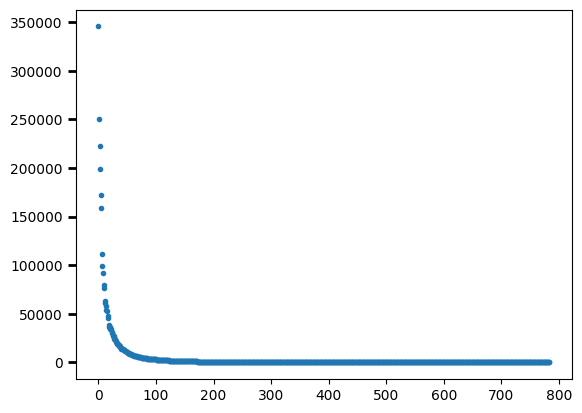

In [12]:
cov_mat = (X_std - mean_vec).T.dot((X_std - mean_vec)) / (X_std.shape[0]-1)
print('Covariance matrix \n%s' %cov_mat)
print('NumPy covariance matrix: \n%s' %np.cov(X_std.T))
cov_mat = np.cov(X_std.T)
from numpy import linalg as LA
values, vectors = LA.eig(cov_mat)

import matplotlib.pyplot as plt
plt.plot(np.sort(values)[::-1],'.')
plt.tick_params(axis='y',length=6, width=2)


In [13]:
np.set_printoptions(precision=2,suppress=True)
values

array([345461.48+0.j, 250042.11+0.j, 222144.04+0.j, 198563.32+0.j,
       172166.12+0.j, 159213.23+0.j, 111376.78+0.j,  99451.49+0.j,
        92369.38+0.j,  79878.7 +0.j,  77003.27+0.j,  62799.79+0.j,
        61098.14+0.j,  57633.83+0.j,  53608.25+0.j,  52586.99+0.j,
        47317.95+0.j,  46061.24+0.j,  38506.37+0.j,  36082.68+0.j,
        36396.35+0.j,  34730.94+0.j,  34083.75+0.j,  31469.09+0.j,
        29815.32+0.j,  28191.17+0.j,  27130.52+0.j,  26721.66+0.j,
        24383.62+0.j,  23889.76+0.j,  22362.54+0.j,  21442.36+0.j,
        19975.34+0.j,  18976.74+0.j,  18785.35+0.j,  17677.4 +0.j,
        17203.96+0.j,  16661.72+0.j,  16349.87+0.j,  15016.11+0.j,
        14215.62+0.j,  14065.9 +0.j,  13976.49+0.j,  13409.05+0.j,
        12749.9 +0.j,  12363.01+0.j,  11873.82+0.j,  11638.24+0.j,
        12098.36+0.j,  10824.04+0.j,  10428.15+0.j,   9920.33+0.j,
         9691.88+0.j,   9387.66+0.j,   9125.76+0.j,   8982.29+0.j,
         8652.08+0.j,   8382.18+0.j,   7883.55+0.j,   7798.72+

You can find Covariance matrix manually or use Library

# USING PCA LIBRARY

In [14]:
from sklearn.decomposition import PCA
pca = PCA(.98) #Keep 98% Eigen Value --> Try to modify this
X_new=pca.fit_transform(X_std)
eig_vals=pca.explained_variance_

print('Eigenvectors \n%s' %pca)
print('\nEigenvalues \n%s' %eig_vals)
print('\n Number of values \n%s' %len(eig_vals))

Eigenvectors 
PCA(n_components=0.98)

Eigenvalues 
[345461.48 250042.11 222144.04 198563.32 172166.12 159213.23 111376.78
  99451.49  92369.38  79878.7   77003.27  62799.79  61098.14  57633.83
  53608.25  52586.99  47317.95  46061.24  38506.37  36396.35  36082.68
  34730.94  34083.75  31469.09  29815.32  28191.17  27130.52  26721.66
  24383.62  23889.76  22362.54  21442.36  19975.34  18976.74  18785.35
  17677.4   17203.96  16661.72  16349.87  15016.11  14215.62  14065.9
  13976.49  13409.05  12749.9   12363.01  12098.36  11873.82  11638.24
  10824.04  10428.15   9920.33   9691.88   9387.66   9125.76   8982.29
   8652.08   8382.18   7883.55   7798.72   7369.12   7349.32   7131.95
   7018.03   6809.2    6609.24   6396.05   6374.27   6091.76   6013.16
   5937.23   5700.53   5652.2    5513.08   5307.21   5084.93   5074.31
   4988.25   4692.99   4638.19   4585.11   4360.05   4300.61   4272.38
   4180.64   4064.52   3929.15   3877.59   3798.05   3708.88   3678.81
   3663.3    3605.38   3553

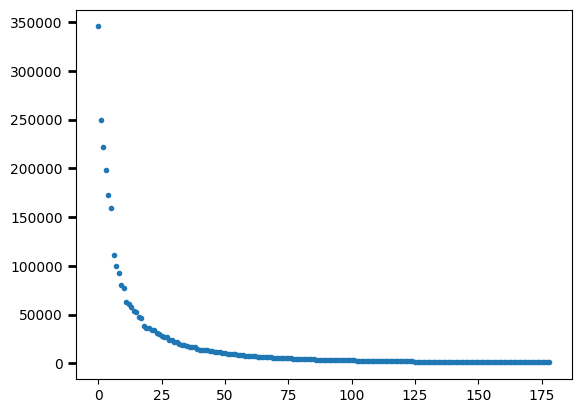

In [15]:
import matplotlib.pyplot as plt
plt.plot(eig_vals,'.')
plt.tick_params(axis='y',length=6, width=2)

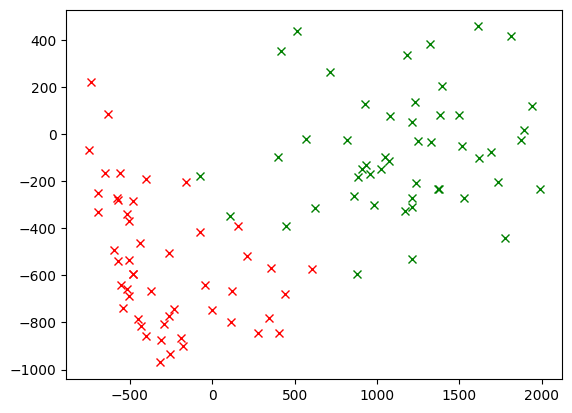

In [16]:
eig_vecs=pca.components_
Projdata=np.dot((X_std-mean_vec),eig_vecs.T)
#Projdata=pca.transform(X_std)

plt.clf()

digit=np.arange(50)#Choose index of the digit ==>0

plt.plot(Projdata[digit,0],Projdata[digit,1],'x',color='g')
digit=digit+200 # Choose another set of index ==>4
plt.plot(Projdata[digit,0],Projdata[digit,1],'x',color='r')

plt.show()

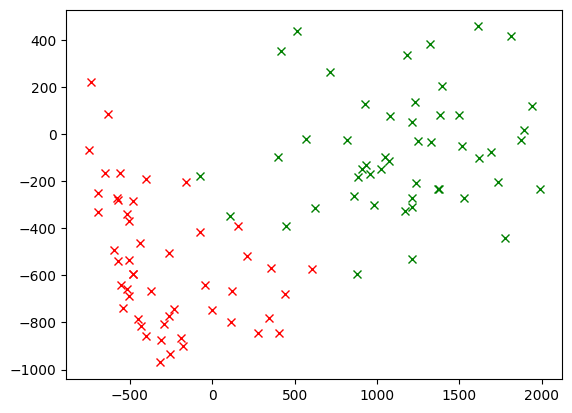

In [17]:
X_proj=pca.transform(X_std)

digit=np.arange(50)#Choose index of the digit

plt.plot(X_proj[digit,0],X_proj[digit,1],'x',color='g')
digit=digit+200 # Choose another set of index
plt.plot(X_proj[digit,0],X_proj[digit,1],'x',color='r')


In [18]:
import matplotlib.pyplot as plt

Projdata=np.dot((X_std-mean_vec),eig_vecs.T) # Make a projection on eigvector



In [19]:
recon=np.dot( Projdata,eig_vecs) #Reversed based on the projection
#recon=pca.inverse_transform(Projdata)
recon.shape

(500, 784)

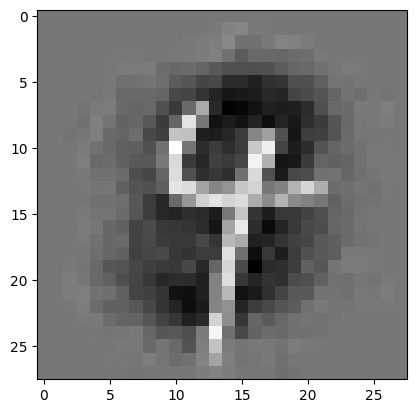

In [20]:
plt.imshow(np.reshape(recon[245],[28,28]),cmap='gray') #index [1] is a selected image of your choice
plt.show()

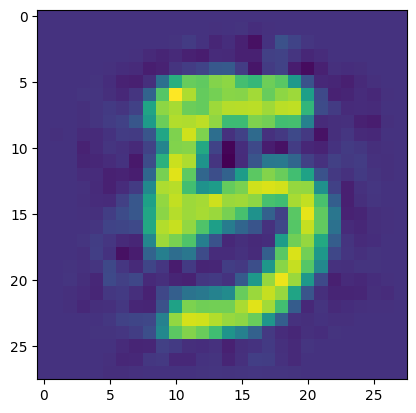

In [21]:
Projdata100=np.dot((X_std-mean_vec),eig_vecs[:100,:].T) # Make a projection on eigvector

recon100=np.dot( Projdata100,eig_vecs[:100,:])+mean_vec
plt.imshow(np.reshape(recon100[266,:],[28,28])) #index [266] --> Digit 5 is a selected image of your choice


In [22]:
eig_vecs.sort

<function ndarray.sort>

In [23]:
print(eig_vecs)

[[-0. -0. -0. ... -0. -0. -0.]
 [-0.  0.  0. ... -0. -0. -0.]
 [ 0. -0. -0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  0.  0.  0.]
 [-0. -0.  0. ...  0.  0.  0.]
 [-0. -0.  0. ... -0. -0. -0.]]


In [24]:


# This is an extremely inefficient function.
def pca_com(com, images):
    # percentage should be a decimal from 0 to 1
    pca = PCA(n_components=com)
    pca.fit(images)
    components = pca.transform(images)
    approxOriginal = pca.inverse_transform(components)
    return approxOriginal

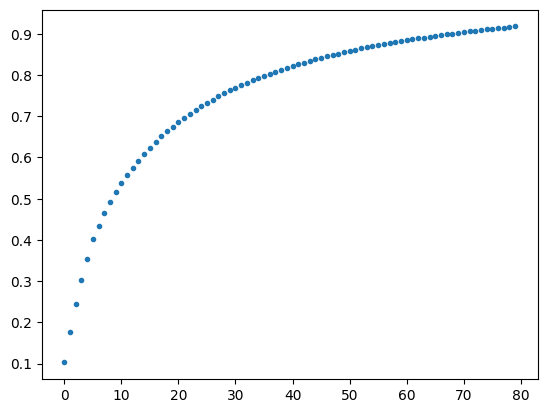

In [25]:
pca = PCA(n_components=80)
pca.fit(X_std)
plt.plot(np.cumsum(pca.explained_variance_ratio_),'.')
plt.show()

<Figure size 640x480 with 0 Axes>

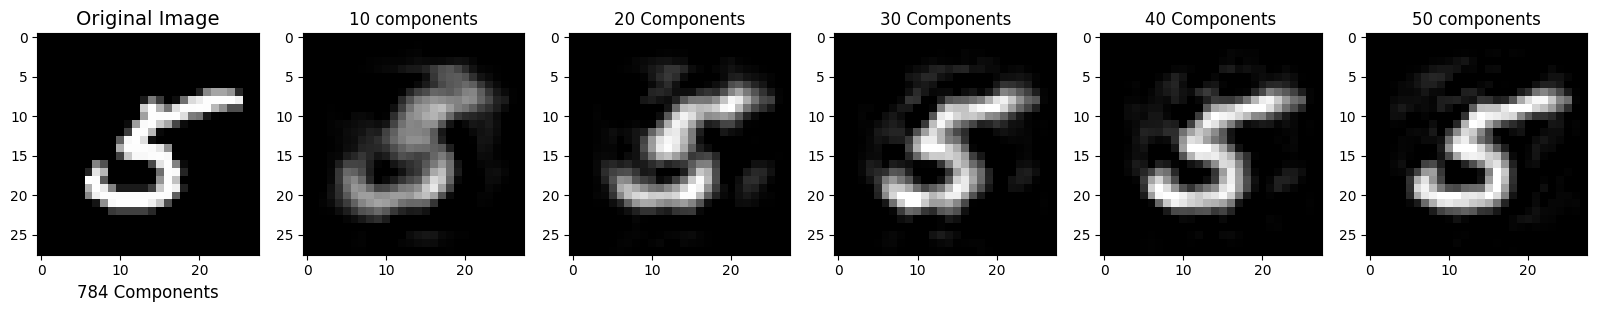

In [26]:
plt.clf()
plt.figure(figsize=(20,4));

# Original Image (784 components)
plt.subplot(1, 6, 1);
plt.imshow(X_std[260,:].reshape(28,28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.xlabel('784 Components', fontsize = 12)
plt.title('Original Image', fontsize = 14);


# 10 principal components
plt.subplot(1, 6, 2);
plt.imshow(pca_com(10, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.title('10 components', fontsize = 12);



# 20 principal components
plt.subplot(1, 6, 3);
plt.imshow(pca_com(20, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.title('20 Components', fontsize = 12)


# 30 principal components
plt.subplot(1, 6, 4);
plt.imshow(pca_com(30, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.title('30 Components', fontsize = 12)


# 40 principal components
plt.subplot(1, 6, 5)
plt.imshow(pca_com(40, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.title('40 Components', fontsize = 12)

# 50 principal components
plt.subplot(1, 6, 6);
plt.imshow(pca_com(50, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.title('50 components', fontsize = 12);
plt.show()



In [27]:
pca = PCA(.99)
pca.fit(X_std)

PCA(n_components=0.99)

In [28]:
pca.n_components_

np.int64(227)

In [29]:
pca_com

<function __main__.pca_com(com, images)>

<Figure size 640x480 with 0 Axes>

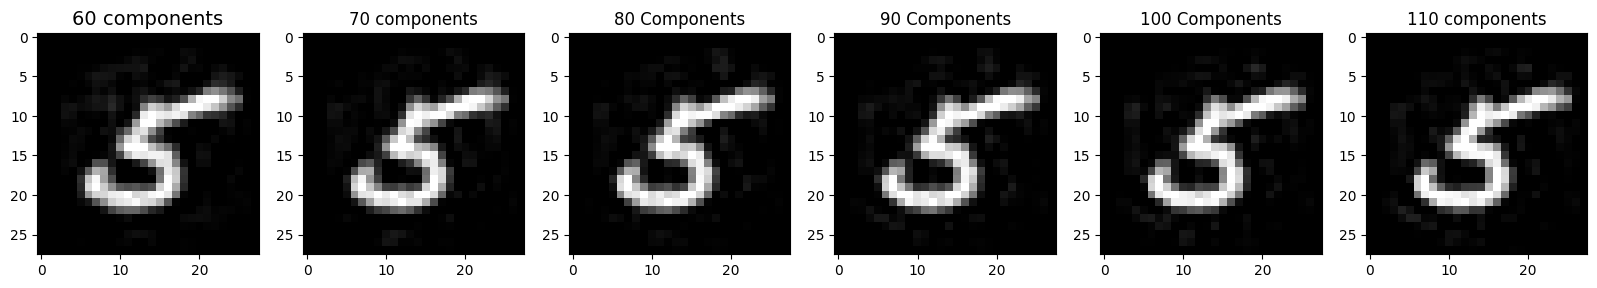

In [30]:
plt.clf()
plt.figure(figsize=(20,4));

# Original Image (784 components)
plt.subplot(1, 6, 1);
plt.imshow(pca_com(60, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));

plt.title('60 components', fontsize = 14);


# 10 principal components
plt.subplot(1, 6, 2);
plt.imshow(pca_com(70, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.title('70 components', fontsize = 12);



# 20 principal components
plt.subplot(1, 6, 3);
plt.imshow(pca_com(80, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.title('80 Components', fontsize = 12)


# 30 principal components
plt.subplot(1, 6, 4);
plt.imshow(pca_com(90, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.title('90 Components', fontsize = 12)


# 40 principal components
plt.subplot(1, 6, 5)
plt.imshow(pca_com(100, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.title('100 Components', fontsize = 12)

# 50 principal components
plt.subplot(1, 6, 6);
plt.imshow(pca_com(110, X_std)[260].reshape(28, 28),
              cmap = plt.cm.gray, interpolation='nearest',
              clim=(0, 255));
plt.title('110 components', fontsize = 12);
plt.show()



#TASK 1 Bayesian Theorem
#Write your own Classifier

In [31]:
X = data.values
from sklearn.model_selection import train_test_split
X_train , X_test, Y_train, Y_test=train_test_split(X[:,:-1],X[:,-1],test_size=0.2,random_state=20)

In [32]:
from sklearn.naive_bayes import GaussianNB

classifier=GaussianNB()
classifier=classifier.fit(X_train,Y_train)
Y_pred=classifier.predict(X_test)

In [33]:
print('The score for training data is', classifier.score(X_train,Y_train))
print('The score for test data is',classifier.score(X_test,Y_test))

The score for training data is 0.8825
The score for test data is 0.7


# TASK 2
##Use the projected image of your Choice (reduce to 100-200 components of your choice + your classifier---> from ealier)


In [6]:
pca = PCA(.98) #choose your percentage
X_train_new=pca.fit_transform(X_train)
X_test_new=pca.transform(X_test)


In [35]:
np.shape(X_test)

(100, 784)

In [34]:
np.shape(X_test_new)

(100, 784)

In [ ]:
#use bayesian

classifier2=GaussianNB()
#Use projected data

# TASK 3
##Use your 2D projection  with your 2 classifiers ( Original Image and projected image) to show the Discrimination regions
#Choose only 2 digits
#Challenge use 10 digits

TASK 4
Print